# CRE3 - Assignment 2: Parametric study of $CO_2$/$CO$ hydrogenation and DME synthesis

Group 6: 

Julian Stierstorfer (1160552)\
Ivana Garzon Casanova ()\
Venkata Uda ()

## 1. Introduction

Assumptions: General approach for the reaction network, continuous operation.

## 2. Reaction network and key reactions

The reaction system that describes the hydrogenation of $CO_2$ and $CO$ as well as the synthesis of DME is given as follows:

\begin{align}
CO_2 + 3H_2 &\overset{R_1}{\rightleftharpoons} CH_3OH + H_2O\\
CO + 2H_2 &\overset{R_2}{\rightleftharpoons} CH_3OH\\
CO_2 + H_2 &\overset{R_3}{\rightleftharpoons} CO + H_2O\\
2CH_3OH &\overset{R_4}{\rightleftharpoons} CH_3OCH_3 + H_2O
\end{align}

Equations (1) and (2) describe the hydrogenation of $CO_2$ and $CO$ while forming methanol ($CH_3OH$). Reaction (3) shows the reverse water-gas shift reaction, while reaction (4) describes the formation of DME from methanol.

### 2.1 Matrix of stoichiometric coefficients

From the reaction equations the Matrix of stoichiometric components can be derived by sorting all components and reactions:

\begin{equation}
  \underline{N} =
    \begin{bmatrix}
          & R_1 & R_2 & R_3 & R_4\\
      CO_2      & -1 & 0  & -1 & 0\\
      H_2       & -3 & -2 & -1 & 0\\
      CH_3OH    & 1  & 1  & 0  & -2\\
      H_2O      & 1  & 0  & 1  & 1\\
      CO        & 0  & -1 & 1  & 0\\
      CH_3OCH_3 & 0  & 0  & 0  & 1
    \end{bmatrix}
\end{equation}

### 2.2 Determining key reactions and components
The number of key reactions and components $R_{\nu}$ is calculated in order to obtain a minimum independent description of the reaction network. Once key reactions and components are known, the linear independent part of the reaction network can be used for a simpler calculation. In practice this also means that by measuring the concentration of key components at a given time, concentration of all other components can be calculated. 

The number of key reactions and components can be calculated as follows [1]:
\begin{equation}
R_\nu = \operatorname{rank}(\underline{N})
\end{equation} 

The rank of $\underline{N}$ can in principle be calculated by applying the Gauss algorithm by hand however this can be done numerically using the `matrix_rank` function by the `linalg`-package by `numpy`. Therefore the initial matrix $\underline{N}_{init}$ is implemented and its rank is calculated.

In [22]:
# importing needed packages
import numpy as np # general numpy package
from numpy.linalg import matrix_rank, det, inv # linear algebra package for matrix rank, determinant and inverse
import matplotlib.pyplot as plt # plotting package


# defining labels for rows (components) and  columns (reactions)
components = ["CO2", "H2", "CH3OH", "H2O", "CO", "CH3OCH3"]
reactions = ["R1", "R2", "R3", "R4"]

N_init = np.array([
    [-1,  0, -1,  0],   # CO2
    [-3, -2, -1,  0],   # H2
    [ 1,  1,  0, -2],   # CH3OH
    [ 1,  0,  1,  1],   # H2O
    [ 0, -1,  1,  0],   # CO
    [ 0,  0,  0,  1]    # CH3OCH3
], dtype=float) # initial matrix of stoichiometric coefficients for the reactions

# Calculate the rank of the stoichiometric matrix
rank_N = matrix_rank(N_init)
print(f"Rank of the stoichiometric matrix N: {rank_N}")



Rank of the stoichiometric matrix N: 3


As obtained from the numerical calculation the rank of the matrix is found. $R_{\nu} = 3$. Therefore, three key components are required. Their selection should consider both practical measurability and chemical relevance, meaning that the chosen components should be experimentally accessible and meaningful for describing the reaction network.

In this case the key components are choosen to be $CO_2$, $CH_3OH$ and $DME$. On the one hand $CO_2$ is one of the carbon feeding species that takes place in hydrogenation, on the other hand $CH_3OH$ and $DME$ represent a critical intermediate as well as the product component.

As well as taking into account key components, key reactions can be determined as well. According to the rank of $\underline{N}$, 3 linear independent key reactions are sufficient to describe the reaction system. After further investigation it can be found that $R_3 = R_1 - R_2$. Therefore the key reactions of the system are $R_1, R_2$ and $R_4$.

Thus the matrix of stoichiometric components can be rearranged according to the key components and reactions:

In [23]:
# Rearranged matrix
# key components first: CO2, CH3OH, CH3OCH3
# remaining components: H2, H2O, CO
row_order = [0, 2, 5, 1, 3, 4]

# independent key reactions first: R1, R2, R4
# dependent reaction R3 last
col_order = [0, 1, 3, 2]

N = N_init[row_order, :][:, col_order]

component_order = ["CO2", "CH3OH", "CH3OCH3", "H2", "H2O", "CO"]
reaction_order = ["R1", "R2", "R4", "R3"]

print("Rearranged matrix N:")
print(N)

print("\nComponent order:")
print(component_order)

print("\nReaction order:")
print(reaction_order)

print("\nRank of rearranged matrix:")
print(matrix_rank(N))

Rearranged matrix N:
[[-1.  0.  0. -1.]
 [ 1.  1. -2.  0.]
 [ 0.  0.  1.  0.]
 [-3. -2.  0. -1.]
 [ 1.  0.  1.  1.]
 [ 0. -1.  0.  1.]]

Component order:
['CO2', 'CH3OH', 'CH3OCH3', 'H2', 'H2O', 'CO']

Reaction order:
['R1', 'R2', 'R4', 'R3']

Rank of rearranged matrix:
3


The rearranged matrix is now given as:

\begin{equation}
  \underline{N} =
    \begin{bmatrix}
          & R_1 & R_2 & R_4 & R_3\\
      CO_2      & -1 & 0  & 0  & -1\\
      CH_3OH    & 1  & 1  & -2 & 0\\
      CH_3OCH_3 & 0  & 0  & 1  & 0\\
      H_2       & -3 & -2 & 0  & -1\\
      H_2O      & 1  & 0  & 1  & 1\\
      CO        & 0  & -1 & 0  & 1
    \end{bmatrix}
\end{equation}

This matrix can now be partitioned into four submatrices:

\begin{equation}
\underline{N} =
\begin{bmatrix}
\underline{N}_{1,1} & \underline{N}_{1,2}\\
\underline{N}_{2,1} & \underline{N}_{2,2}
\end{bmatrix} =
\left[
\begin{array}{ccc|c}
-1 & 0  & 0  & -1\\
 1 & 1  & -2 & 0\\
 0 & 0  & 1  & 0\\
\hline
-3 & -2 & 0  & -1\\
 1 & 0  & 1  & 1\\
 0 & -1 & 0  & 1
\end{array}
\right]
\end{equation}





In [24]:
# Calculate the rank of the rearranged matrix
R_nu = matrix_rank(N)

# Split matrix into submatrices
N_11 = N[:R_nu, :R_nu]
N_12 = N[:R_nu, R_nu:]
N_21 = N[R_nu:, :R_nu]
N_22 = N[R_nu:, R_nu:]

print("\nN_11:")
print(N_11)

print("\nN_12:")
print(N_12)

print("\nN_21:")
print(N_21)

print("\nN_22:")
print(N_22)




N_11:
[[-1.  0.  0.]
 [ 1.  1. -2.]
 [ 0.  0.  1.]]

N_12:
[[-1.]
 [ 0.]
 [ 0.]]

N_21:
[[-3. -2.  0.]
 [ 1.  0.  1.]
 [ 0. -1.  0.]]

N_22:
[[-1.]
 [ 1.]
 [ 1.]]


### 2.3 Reaction Extent
The stoichiometric changes during the reaction can be investigated by using the reaction extent $\xi_j$ which can be derived from the generall mass balance. The reaction extent takes into account the difference in molar flow between input and output stream for every component:

\begin{align}
  \underline{\dot n}_{out}-\underline{\dot n}_{in} =\Delta\underline{\dot n} = \underline{N}\,\underline{\dot\xi}
\end{align}

$\Delta\underline{\dot n}$ contains the overall conversion of the key components ($\Delta\underline{\dot n_1}$) as well as the non-key components ($\Delta\underline{\dot n_2}$)

\begin{equation}
  \Delta\underline{\dot n}=
    \begin{bmatrix}
      \Delta\underline{\dot n}_{1}\\
      \\
      \Delta\underline{\dot n}_{2}
    \end{bmatrix}%^1_2
\end{equation}

While the conversion of the key components is known (e.g. from measurements) the conversion of the non-key components can be calculated:

\begin{equation}
  \Delta\underline{\dot n}_{2} = \underline{N}_{21}\,\underline{N}_{11}^{-1}\,\Delta\underline{\dot n}_{1}
\end{equation}

Therefore, $\underline{N}_{11}$ has to be invertible in the first place. This can be checked by calculating the determinant of the matrix which is done by using the `det`-function of `numpy`'s `linalg`-package:

In [25]:
print("\ndet(N_11):")
print(det(N_11))


det(N_11):
-1.0


Since $\det\left(\underline{N}_{1,1}\right) \neq 0$, this is guaranteed.

### 2.4 Conversion

For the given system an input molar flow for all components is assumed:

\begin{equation}
\dot{\underline{n}}_{in} =
\begin{bmatrix}
10.0 & CO_2\\
0.2  & CH_3OH\\
0.3  & CH_3OCH_3\\
30.0 & H_2\\
0.69  & H_2O\\
2.0  & CO
\end{bmatrix}
\ \mathrm{mol\,s^{-1}}
\end{equation}

The conversion of the key components wcan be measured and is in this case assumed to be:

\begin{equation}
\Delta \dot{\underline{n}}_1 =
\begin{bmatrix}
-5.5 & CO_2\\
 1.0 & CH_3OH\\
 1.0 & CH_3OCH_3
\end{bmatrix}
\ \mathrm{mol\,s^{-1}}
\end{equation}

The conversion of the non-key components $\Delta\underline{\dot n_2}$ as well as the reaction extent $\dot{\underline{\xi}}$ of the key reactions can now be calculated:

In [26]:
# New inlet molar flow vector
# order: CO2, CH3OH, CH3OCH3, H2, H2O, CO
n_in = np.array([
    10.0,   # CO2
     0.2,   # CH3OH
     0.3,   # CH3OCH3
    30.0,   # H2
     0.69,  # H2O
     2.0    # CO
])

# Measured / assumed change of key-component molar flows
# order: CO2, CH3OH, CH3OCH3
delta_n_1 = np.array([
    -5.5,   # CO2
     1.0,   # CH3OH
     1.0    # CH3OCH3
])

# Calculate change of non-key-component molar flows
# Δn_2 = N_21 @ inv(N_11) @ Δn_1
delta_n_2 = N_21 @ np.linalg.inv(N_11) @ delta_n_1

# Calculate reaction extent vector
# ξ = inv(N_11) @ Δn_1
reaction_extent = inv(N_11) @ delta_n_1

print("\nReaction extent vector of key reactions:")
for reaction, value in zip(reaction_order[:R_nu], reaction_extent):
    print(f"{reaction}: {value:.3f} mol/s")

print("Delta n_1:")
print(delta_n_1)

print("\nDelta n_2:")
print(delta_n_2)

non_key_components = ["H2", "H2O", "CO"]

print("\nCalculated changes of non-key components:")
for component, value in zip(non_key_components, delta_n_2):
    print(f"{component}: {value:.3f} mol/s")

    


Reaction extent vector of key reactions:
R1: 5.500 mol/s
R2: -2.500 mol/s
R4: 1.000 mol/s
Delta n_1:
[-5.5  1.   1. ]

Delta n_2:
[-11.5   6.5   2.5]

Calculated changes of non-key components:
H2: -11.500 mol/s
H2O: 6.500 mol/s
CO: 2.500 mol/s


The calculated non-key componant changes are:

\begin{equation}
\Delta \dot{\underline{n}}_2 =
\begin{bmatrix}
-11.500 & H_2\\
  6.500 & H_2O\\
  2.500 & CO
\end{bmatrix}
\ \mathrm{mol\,s^{-1}}
\end{equation}

The reaction extent of the key reactions is calculated as:

\begin{equation}
\dot{\underline{\xi}} =
\begin{bmatrix}
 5.500 & R_1\\
-2.500 & R_2\\
 1.000 & R_4
\end{bmatrix}
\ \mathrm{mol\,s^{-1}}
\end{equation}

From this, the total output flow rates are calculated:

\begin{equation}
\dot{\underline{n}}_{out}
=
\dot{\underline{n}}_{in}
+
\Delta \dot{\underline{n}}
\end{equation}

In [27]:
# Combine key and non-key component changes
delta_n = np.concatenate((delta_n_1, delta_n_2))

# Calculate outlet molar flow
# n_out = n_in + Δn
n_out = n_in + delta_n

print("Change of key components Δn_1:")
for component, value in zip(component_order[:R_nu], delta_n_1):
    print(f"{component}: {value:.3f} mol/s")

print("\nCalculated change of non-key components Δn_2:")
for component, value in zip(component_order[R_nu:], delta_n_2):
    print(f"{component}: {value:.3f} mol/s")

print("\nTotal change vector Δn:")
for component, value in zip(component_order, delta_n):
    print(f"{component}: {value:.3f} mol/s")

print("\nOutlet molar flow n_out:")
for component, value in zip(component_order, n_out):
    print(f"{component}: {value:.3f} mol/s")

Change of key components Δn_1:
CO2: -5.500 mol/s
CH3OH: 1.000 mol/s
CH3OCH3: 1.000 mol/s

Calculated change of non-key components Δn_2:
H2: -11.500 mol/s
H2O: 6.500 mol/s
CO: 2.500 mol/s

Total change vector Δn:
CO2: -5.500 mol/s
CH3OH: 1.000 mol/s
CH3OCH3: 1.000 mol/s
H2: -11.500 mol/s
H2O: 6.500 mol/s
CO: 2.500 mol/s

Outlet molar flow n_out:
CO2: 4.500 mol/s
CH3OH: 1.200 mol/s
CH3OCH3: 1.300 mol/s
H2: 18.500 mol/s
H2O: 7.190 mol/s
CO: 4.500 mol/s


The total change in flow of all components is calculated as:

\begin{equation}
\Delta \dot{\underline{n}} =
\begin{bmatrix}
-5.500 & CO_2\\
 1.000 & CH_3OH\\
 1.000 & CH_3OCH_3\\
-11.500 & H_2\\
 6.500 & H_2O\\
 2.500 & CO
\end{bmatrix}
\ \mathrm{mol\,s^{-1}}
\end{equation}

Therefore the output flow of all components is:

\begin{equation}
\dot{\underline{n}}_{out} =
\begin{bmatrix}
 4.500 & CO_2\\
 1.200 & CH_3OH\\
 1.300 & CH_3OCH_3\\
18.500 & H_2\\
 7.190 & H_2O\\
 4.500 & CO
\end{bmatrix}
\ \mathrm{mol\,s^{-1}}
\end{equation}

### 2.5 Plausibility check using atom balance

To verify the integrity of the code and the plausibility of the conducted calculations, an atom balance can be used.
Therefore, atom molar flow vectors $\dot{\underline{b}}$ are created that contain the molar flow rates of each atom species.
 Since chemical reactions do not create or destroy atoms, the total molar flow of each element must be identical at inlet and outlet:

\begin{equation}
\dot{\underline{b}}_{in} =
\begin{bmatrix}
\dot{b}_{C,in}\\
\dot{b}_{H,in}\\
\dot{b}_{O,in}
\end{bmatrix} =
\dot{\underline{b}}_{out} =
\begin{bmatrix}
\dot{b}_{C,out}\\
\dot{b}_{H,out}\\
\dot{b}_{O,out}
\end{bmatrix}
\end{equation}

Also the element-species matrix $\underline{B}$ has to be taken into account. Each of its columns represents a component while each row represents an element of the reaction network. In this case the element-species matrix can be formed as:

\begin{equation}
\underline{B} =
\begin{bmatrix}
      & CO_2 & CH_3OH & CH_3OCH_3 & H_2 & H_2O & CO\\
C     & 1    & 1      & 2         & 0   & 0    & 1\\
H     & 0    & 4      & 6         & 2   & 2    & 0\\
O     & 2    & 1      & 1         & 0   & 1    & 1
\end{bmatrix}
\end{equation}

The inlet and outlet atom flows can be calculated:

\begin{equation}
    \underline{\dot{b}_{in}} = \underline{B \dot{n}_{in}}
\end{equation}

where $\dot{n}_{in}$ is the molar flow vector of all components. Same can be applied to the outlet stream.
To validate the calculation, the following must hold:

\begin{equation}
    \dot{\underline{b}}_{in} = \dot{\underline{b}}_{out} 
\end{equation}


In [28]:
# Element-species matrix B
# rows: C, H, O
# columns: CO2, CH3OH, CH3OCH3, H2, H2O, CO
B = np.array([
    [1, 1, 2, 0, 0, 1],  # C atoms
    [0, 4, 6, 2, 2, 0],  # H atoms
    [2, 1, 1, 0, 1, 1]   # O atoms
], dtype=float)

elements = ["C", "H", "O"]

# Calculate element flows
b_in = B @ n_in # calculation of element flow at inlet using matrix multiplication of B and n_in (@ is the matrix multiplication operator in numpy)
b_out = B @ n_out
b_difference = b_out - b_in

print("\nAtom balance check:")
for element, inlet, outlet, diff in zip(elements, b_in, b_out, b_difference):
    print(
        f"{element}: "
        f"in : {inlet:.6f} mol atoms/s, "
        f"out : {outlet:.6f} mol atoms/s, "
        f"difference : {diff:.2e}"
    )

if np.allclose(b_in, b_out):
    print("\nAtom balance is fulfilled.")
else:
    print("\nAtom balance is NOT fulfilled.")


Atom balance check:
C: in : 12.800000 mol atoms/s, out : 12.800000 mol atoms/s, difference : 0.00e+00
H: in : 63.980000 mol atoms/s, out : 63.980000 mol atoms/s, difference : -7.11e-15
O: in : 23.190000 mol atoms/s, out : 23.190000 mol atoms/s, difference : -3.55e-15

Atom balance is fulfilled.


The atom balance is fullfilled in this case. That means that every atom that makes up the inlet flow is also present in the outlet flow. Therefore the calculation of the conversion is valid.

Optionally, the overall mass balance can be used to verify the calculations. In this case, the molar mass $M_i$ of every component can be used to calculate inlet and outlet mass flowrates $\underline{\dot{m}}_{in}$ and $\underline{\dot{m}}_{out}$.

The overall inlet and outlet mass flows can be calculated:
\begin{equation}
    \dot{m}_{in}
    =
    \sum_{i=1}^{N}
    \dot{n}_{in,i} \, M_i
\end{equation}

\begin{equation}
    \dot{m}_{out}
    =
    \sum_{i=1}^{N}
    \dot{n}_{out,i} \, M_i
\end{equation}

Comparing the mass flowrates, the difference should be (numerically close to) zero.

In [29]:
# Optional mass balance check

# Molar masses in g/mol
# order: CO2, CH3OH, CH3OCH3, H2, H2O, CO
M = np.array([
    44.01,   # CO2
    32.04,   # CH3OH
    46.07,   # CH3OCH3
    2.016,   # H2
    18.015,  # H2O
    28.01    # CO
])

m_in = np.sum(n_in * M)
m_out = np.sum(n_out * M)
m_difference = m_out - m_in

print("\nMass balance check:")
print(f"m_in  = {m_in:.6f} g/s")
print(f"m_out = {m_out:.6f} g/s")
print(f"difference = {m_difference:.2e} g/s")



Mass balance check:
m_in  = 589.259350 g/s
m_out = 589.252850 g/s
difference = -6.50e-03 g/s


Therefore the mass balance should be fulfilled by a margin of error that is not significant for the given inlet and outlet streams.

### 2.6 Discussion

The matrix-based analysis provides a systematic way to describe the stoichiometric structure of the DME reaction network. By arranging the stoichiometric coefficients in the matrix $\underline{N}$, linear dependencies between the reactions can be identified. Although four reactions are considered, the rank of the matrix is only three. Therefore, only three reactions are stoichiometrically independent and sufficient for the reduced description of the system.

Based on this rank, three key components are required. The selected key components $CO_2$, $CH_3OH$, and $CH_3OCH_3$ are suitable because they represent the main pathway from the carbon-containing feed component to the intermediate methanol and finally to the desired product DME. After rearranging the matrix, the submatrix $\underline{N}_{1,1}$ was shown to be invertible. Thus, the selected key components and key reactions are valid.

Using the measured changes of the key components, the reaction extent vector and the changes of the non-key components can be calculated. This allows the complete outlet molar flow vector to be determined without measuring every component directly. The plausibility of the calculated outlet flows was checked using atom and mass balances. Since the atom flows of carbon, hydrogen, and oxygen are conserved, the calculation is stoichiometrically consistent.

### 2.7 Conclusion

The matrix-based method is a useful tool for analyzing complex reaction networks. For the considered DME reaction system, the rank of the stoichiometric matrix shows that three independent key reactions are sufficient. The chosen key components $CO_2$, $CH_3OH$, and $CH_3OCH_3$ provide a meaningful description of the main reaction pathway.

By combining the stoichiometric matrix, submatrix partitioning, and general balance equations, the outlet molar flows can be calculated from the measured changes of the key components. The fulfilled atom balance confirms that the calculations are plausible and consistent with the conservation of atoms.

## 3. Thermodynamic properties and equilibrium calculations

In order to calculate the equilibrium yield of DME, the required thermodynamic data have to be studied first. The equilibrium composition of the reaction system depends strongly on temperature, pressure, and the thermodynamic properties of the involved species.

For this purpose, temperature-dependent values of heat capacity, enthalpy, entropy, and Gibbs free energy are required for all components in the reaction network. These data are needed to calculate the reaction enthalpy, reaction entropy, and Gibbs free energy of each reaction. Based on the Gibbs free energy, the equilibrium constants can then be determined.

Therefore, the following section focuses on the selection and implementation of suitable thermodynamic data for the components $CO_2$, $H_2$, $CH_3OH$, $H_2O$, $CO$, and $CH_3OCH_3$. These data provide the basis for the later calculation of the chemical equilibrium and the resulting DME yield.

### 3.1 Thermodynamic data of species

The first step is to obtain thermodynamic standard data $H_{i}^{\circ}$, $S_{i}^{\circ}$ and $G_{i}^{\circ}$ for all species $i$.
This can be accomplished by using either the Shomate or Glenn euqations. Both empirical equations use a similar approach and are dependent on specific coefficients.

Glenn-equations:
$$
\frac{C_{p}^{\circ}(T)}{R}
= a_1 T^{-2}
+ a_2 T^{-1}
+ a_3
+ a_4 T
+ a_5 T^2
+ a_6 T^3
+ a_7 T^4
$$

$$
\frac{H^\circ(T)}{RT}
= -a_1 T^{-2}
+ \frac{a_2 \ln T}{T}
+ a_3
+ \frac{a_4 T}{2}
+ \frac{a_5 T^2}{3}
+ \frac{a_6 T^3}{4}
+ \frac{a_7 T^4}{5}
+ \frac{b_1}{T}
$$

$$
\frac{S^\circ(T)}{R}
= -\frac{a_1 T^{-2}}{2}
- a_2 T^{-1}
+ a_3 \ln T
+ a_4 T
+ \frac{a_5 T^2}{2}
+ \frac{a_6 T^3}{3}
+ \frac{a_7 T^4}{4}
+ b_2
$$

where $T$ is the temperature and $a_i$ are the Glenn parameters.

Shomate-equations:

$$
C_p^\circ
= A
+ B \cdot t
+ C \cdot t^2
+ D \cdot t^3
+ \frac{E}{t^2}
$$

$$
H^\circ - H^\circ_{298.15}
= A \cdot t
+ \frac{B \cdot t^2}{2}
+ \frac{C \cdot t^3}{3}
+ \frac{D \cdot t^4}{4}
- \frac{E}{t}
+ F
- H
$$

$$
S^\circ
= A \cdot \ln(t)
+ B \cdot t
+ \frac{C \cdot t^2}{2}
+ \frac{D \cdot t^3}{3}
- \frac{E}{2 \cdot t^2}
+ G
$$

where $t = \frac{T}{1000 K}$ is the dimensionless temperature and $A$ to $G$ are the Shomate parameters.

For the given components, Shomate parameters are retrrieved from the [NIST Chemistry WebBook](https://webbook.nist.gov/) and sorted by the specific component as well as the given temperature range [2]:

| Species | $T_{\min}$ / K | $T_{\max}$ / K | $A$ | $B$ | $C$ | $D$ | $E$ | $F$ | $G$ | $H$ |
|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| $H_2$ | 298 | 1000 | 33.066178 | -11.363417 | 11.432816 | -2.772874 | -0.158558 | -9.980797 | 172.707974 | 0.000000 |
| $H_2$ | 1000 | 2500 | 18.563083 | 12.257357 | -2.859786 | 0.268238 | 1.977990 | -1.147438 | 156.288133 | 0.000000 |
| $H_2$ | 2500 | 6000 | 43.413560 | -4.293079 | 1.272428 | -0.096876 | -20.533862 | -38.515158 | 162.081354 | 0.000000 |
| $CO_2$ | 298 | 1200 | 24.997350 | 55.186960 | -33.691370 | 7.948387 | -0.136638 | -403.607500 | 228.243100 | -393.522400 |
| $CO_2$ | 1200 | 6000 | 58.166390 | 2.720074 | -0.492289 | 0.038844 | -6.447293 | -425.918600 | 263.612500 | -393.522400 |
| $CO$ | 298 | 1300 | 25.567590 | 6.096130 | 4.054656 | -2.671301 | 0.131021 | -118.008900 | 227.366500 | -110.527100 |
| $CO$ | 1300 | 6000 | 35.150700 | 1.300095 | -0.205921 | 0.013550 | -3.282780 | -127.837500 | 231.712000 | -110.527100 |
| $H_2O$ | 500 | 1700 | 30.092000 | 6.832514 | 6.793435 | -2.534480 | 0.082139 | -250.881000 | 223.396700 | -241.826400 |
| $H_2O$ | 1700 | 6000 | 41.964260 | 8.622053 | -1.499780 | 0.098119 | -11.157640 | -272.179700 | 219.780900 | -241.826400 |
| $CH_3OH$ | - | - | - | - | - | - | - | - | - | - |
| $CH_3OCH_3$ | - | - | - | - | - | - | - | - | - | - |

As seen here, Shomate parameters for $CH_3OH$ and $DME$ are not provided. Therefore the NASA-Glenn polynomial coefficients have to be used [3].

| Species | $T_{\min}$ / K | $T_{\max}$ / K | $a_1$ | $a_2$ | $a_3$ | $a_4$ | $a_5$ | $a_6$ | $a_7$ | $b_1$ | $b_2$ |
|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| $CH_3OCH_3$ | 200 | 1000 | -2.693103242e+05 | 4.300709710e+03 | -2.152788028e+01 | 8.131833390e-02 | -8.295671320e-05 | 4.801911510e-08 | -1.188699808e-11 | -4.410237090e+04 | 1.467666934e+02 |
| $CH_3OCH_3$ | 1000 | 6000 | 4.933577190e+06 | -2.083094065e+04 | 3.629050610e+01 | -4.108351640e-03 | 7.903220310e-07 | -8.131435630e-11 | 3.458166110e-15 | 1.013301012e+05 | -2.185447466e+02 |
| $CH_3OH$ | 200 | 1000 | -2.416642886e+05 | 4.032147190e+03 | -2.046415436e+01 | 6.903698070e-02 | -7.598932690e-05 | 4.598208360e-08 | -1.158706744e-11 | -4.433261170e+04 | 1.400142190e+02 |
| $CH_3OH$ | 1000 | 6000 | 3.411570760e+06 | -1.345500201e+04 | 2.261407623e+01 | -2.141029179e-03 | 3.730050540e-07 | -3.498846390e-11 | 1.366073444e-15 | - | - |

All parameters are now implemented into Python using a dictionary. The values are now sorted by specific component and temperature range. In order to access all parameters, general `Get`-functions are implemented (`get_shomate_coefficients` and `get_glenn_coefficients`). Any paramter listet as "None" is treated as zero which is accomplished by the `replace_none_with_zero`-function. At last, the `get_thermo_coefficients`-function is defined. Its purpose is to provide a central access to all thermodynamic coefficients. The function automatically checks if Shomate-paramters are listed. If so, those are used for further calculation. If no Shomate coefficients are present, the function will automatically choose Glenn-coefficients. Therefore, the primary calculation is done by using the Shomate-equation while the use of the Glenn-equation is a backup option in case Shomate-paramters a not known. This is also done for convenience. While Glenn-paramters need to be looked up in quite a long single publication [3], Shomate-parameters can be found in the NIST online-database [2].


In [30]:
# Universal gas constant
R = 8.314462618  # J mol-1 K-1

# 1. Shomate parameters
# Shomate form:
#
# Cp° = A + B*t + C*t2 + D*t3 + E/t2
#
# H° - H°298.15 = A*t + B*t2/2 + C*t3/3 + D*t4/4 - E/t + F - H
#
# S° = A*ln(t) + B*t + C*t2/2 + D*t3/3 - E/(2*t2) + G
#
# with:
# t = T / 1000
#
# Units:
# Cp°: J mol-1 K-1
# H° - H°298.15: kJ mol-1
# S°: J mol-1 K-1

shomate_coefficients = {
    "H2": {
        "name": "Hydrogen",
        "temperature_ranges": [
            {
                "T_min": 298.0,
                "T_max": 1000.0,
                "coefficients": {
                    "A": 33.066178,
                    "B": -11.363417,
                    "C": 11.432816,
                    "D": -2.772874,
                    "E": -0.158558,
                    "F": -9.980797,
                    "G": 172.707974,
                    "H": 0.000000,
                },
            },
            {
                "T_min": 1000.0,
                "T_max": 2500.0,
                "coefficients": {
                    "A": 18.563083,
                    "B": 12.257357,
                    "C": -2.859786,
                    "D": 0.268238,
                    "E": 1.977990,
                    "F": -1.147438,
                    "G": 156.288133,
                    "H": 0.000000,
                },
            },
            {
                "T_min": 2500.0,
                "T_max": 6000.0,
                "coefficients": {
                    "A": 43.413560,
                    "B": -4.293079,
                    "C": 1.272428,
                    "D": -0.096876,
                    "E": -20.533862,
                    "F": -38.515158,
                    "G": 162.081354,
                    "H": 0.000000,
                },
            },
        ],
    },

    "CO2": {
        "name": "Carbon dioxide",
        "temperature_ranges": [
            {
                "T_min": 298.0,
                "T_max": 1200.0,
                "coefficients": {
                    "A": 24.997350,
                    "B": 55.186960,
                    "C": -33.691370,
                    "D": 7.948387,
                    "E": -0.136638,
                    "F": -403.607500,
                    "G": 228.243100,
                    "H": -393.522400,
                },
            },
            {
                "T_min": 1200.0,
                "T_max": 6000.0,
                "coefficients": {
                    "A": 58.166390,
                    "B": 2.720074,
                    "C": -0.492289,
                    "D": 0.038844,
                    "E": -6.447293,
                    "F": -425.918600,
                    "G": 263.612500,
                    "H": -393.522400,
                },
            },
        ],
    },

    "CO": {
        "name": "Carbon monoxide",
        "temperature_ranges": [
            {
                "T_min": 298.0,
                "T_max": 1300.0,
                "coefficients": {
                    "A": 25.567590,
                    "B": 6.096130,
                    "C": 4.054656,
                    "D": -2.671301,
                    "E": 0.131021,
                    "F": -118.008900,
                    "G": 227.366500,
                    "H": -110.527100,
                },
            },
            {
                "T_min": 1300.0,
                "T_max": 6000.0,
                "coefficients": {
                    "A": 35.150700,
                    "B": 1.300095,
                    "C": -0.205921,
                    "D": 0.013550,
                    "E": -3.282780,
                    "F": -127.837500,
                    "G": 231.712000,
                    "H": -110.527100,
                },
            },
        ],
    },

    "H2O": {
        "name": "Water",
        "temperature_ranges": [
            {
                "T_min": 500.0,
                "T_max": 1700.0,
                "coefficients": {
                    "A": 30.092000,
                    "B": 6.832514,
                    "C": 6.793435,
                    "D": -2.534480,
                    "E": 0.082139,
                    "F": -250.881000,
                    "G": 223.396700,
                    "H": -241.826400,
                },
            },
            {
                "T_min": 1700.0,
                "T_max": 6000.0,
                "coefficients": {
                    "A": 41.964260,
                    "B": 8.622053,
                    "C": -1.499780,
                    "D": 0.098119,
                    "E": -11.157640,
                    "F": -272.179700,
                    "G": 219.780900,
                    "H": -241.826400,
                },
            },
        ],
    },

    "CH3OH": {
        "name": "Methanol",
        "temperature_ranges": [],
    },

    "CH3OCH3": {
        "name": "Dimethyl ether",
        "temperature_ranges": [],
    },
}


# 2. Glenn/NASA coefficients
# Glenn/NASA 9-coefficient form:
#
# Cp° / R = a1*T-2 + a2*T-1 + a3 + a4*T + a5*T2 + a6*T3 + a7*T4
#
# H° / (R*T) = -a1*T-2 + a2*ln(T)/T + a3
#              + a4*T/2 + a5*T2/3 + a6*T3/4 + a7*T4/5 + b1/T
#
# S° / R = -a1/(2*T2) - a2/T + a3*ln(T)
#          + a4*T + a5*T2/2 + a6*T3/3 + a7*T4/4 + b2


glenn_coefficients = {
    "CH3OCH3": {
        "name": "Dimethyl ether",
        "molar_mass": 46.0684400,   # g mol-1
        "hf_298": -184110.000,      # J mol-1
        "temperature_ranges": [
            {
                "T_min": 200.0,
                "T_max": 1000.0,
                "coefficients": {
                    "a1": -2.693103242e05,
                    "a2":  4.300709710e03,
                    "a3": -2.152788028e01,
                    "a4":  8.131833390e-02,
                    "a5": -8.295671320e-05,
                    "a6":  4.801911510e-08,
                    "a7": -1.188699808e-11,
                    "b1": -4.410237090e04,
                    "b2":  1.467666934e02,
                },
            },
            {
                "T_min": 1000.0,
                "T_max": 6000.0,
                "coefficients": {
                    "a1":  4.933577190e06,
                    "a2": -2.083094065e04,
                    "a3":  3.629050610e01,
                    "a4": -4.108351640e-03,
                    "a5":  7.903220310e-07,
                    "a6": -8.131435630e-11,
                    "a7":  3.458166110e-15,
                    "b1":  1.013301012e05,
                    "b2": -2.185447466e02,
                },
            },
        ],
    },

    "CH3OH": {
        "name": "Methanol",
        "molar_mass": 32.0418600,   # g mol-1
        "hf_298": -200940.000,      # J mol-1
        "temperature_ranges": [
            {
                "T_min": 200.0,
                "T_max": 1000.0,
                "coefficients": {
                    "a1": -2.416642886e05,
                    "a2":  4.032147190e03,
                    "a3": -2.046415436e01,
                    "a4":  6.903698070e-02,
                    "a5": -7.598932690e-05,
                    "a6":  4.598208360e-08,
                    "a7": -1.158706744e-11,
                    "b1": -4.433261170e04,
                    "b2":  1.400142190e02,
                },
            },
            {
                "T_min": 1000.0,
                "T_max": 6000.0,
                "coefficients": {
                    "a1":  3.411570760e06,
                    "a2": -1.345500201e04,
                    "a3":  2.261407623e01,
                    "a4": -2.141029179e-03,
                    "a5":  3.730050540e-07,
                    "a6": -3.498846390e-11,
                    "a7":  1.366073444e-15,
                    "b1": None,
                    "b2": None,
                },
            },
        ],
    },
}


# 3. Helper function for missing parameters

def replace_none_with_zero(coefficients, species):
    """
    Replace all None values in a coefficient dictionary with 0.0.

    If a coefficient is not determined, a message is printed.
    """

    corrected_coefficients = coefficients.copy()

    for key, value in corrected_coefficients.items():
        if value is None:
            print(f"{key} for component {species} not determined, therefore treated as 0.")
            corrected_coefficients[key] = 0.0

    return corrected_coefficients


# 4. Get-function for Shomate coefficients

def get_shomate_coefficients(species, T, database=shomate_coefficients):
    """
    Return Shomate coefficients for a species at temperature T.

    If any coefficient value is None, it is replaced by 0.0.
    """

    if species not in database:
        raise KeyError(f"Species '{species}' is not available in the Shomate database.")

    ranges = database[species]["temperature_ranges"]

    if len(ranges) == 0:
        raise ValueError(
            f"No Shomate parameters available for {species}. "
            "Use another data source, for example Glenn/NASA coefficients."
        )

    for interval in ranges:
        if interval["T_min"] <= T <= interval["T_max"]:
            coeffs = interval["coefficients"]
            coeffs = replace_none_with_zero(coeffs, species)
            return coeffs

    raise ValueError(f"No Shomate coefficients available for {species} at T = {T} K.")


# 5. Get-function for Glenn/NASA coefficients

def get_glenn_coefficients(species, T, database=glenn_coefficients):
    """
    Return Glenn/NASA coefficients for a species at temperature T.

    If any coefficient value is None, it is replaced by 0.0.
    """

    if species not in database:
        raise KeyError(f"Species '{species}' is not available in the Glenn database.")

    ranges = database[species]["temperature_ranges"]

    for interval in ranges:
        if interval["T_min"] <= T <= interval["T_max"]:
            coeffs = interval["coefficients"]
            coeffs = replace_none_with_zero(coeffs, species)
            return coeffs

    raise ValueError(f"No Glenn coefficients available for {species} at T = {T} K.")


# 6. General get-function for thermodynamic coefficients

def get_thermo_coefficients(species, T):
    """
    Select the correct thermodynamic coefficient set for a species at temperature T.

    Priority:
    1. Shomate coefficients
    2. NASA-Glenn coefficients

    None values are replaced by 0.0.
    """

    # Try Shomate first
    if species in shomate_coefficients:
        for interval in shomate_coefficients[species]["temperature_ranges"]:
            if interval["T_min"] <= T <= interval["T_max"]:
                coeffs = interval["coefficients"]
                coeffs = replace_none_with_zero(coeffs, species)
                return "Shomate", coeffs

    # If no valid Shomate interval exists, try NASA-Glenn
    if species in glenn_coefficients:
        for interval in glenn_coefficients[species]["temperature_ranges"]:
            if interval["T_min"] <= T <= interval["T_max"]:
                coeffs = interval["coefficients"]
                coeffs = replace_none_with_zero(coeffs, species)
                return "Glenn", coeffs

    raise ValueError(f"No valid thermodynamic data found for {species} at T = {T} K.")

Now, Shomate- and Glenn-equations are implemented:

In [35]:
# Shomate calculation functions


def calculate_shomate_heat_capacity(T, coeffs):
    """
    Calculate Cp using the Shomate equation.

    Returns
    -------
    Cp : float
        Heat capacity in J mol-1 K-1
    """

    t = T / 1000.0

    A = coeffs["A"]
    B = coeffs["B"]
    C = coeffs["C"]
    D = coeffs["D"]
    E = coeffs["E"]

    Cp = A + B*t + C*t**2 + D*t**3 + E/t**2

    return Cp


def calculate_shomate_enthalpy(T, coeffs):
    """
    Calculate standard enthalpy using the Shomate equation.

    Returns
    -------
    H : float
        Standard enthalpy in kJ mol-1
    """

    t = T / 1000.0

    A = coeffs["A"]
    B = coeffs["B"]
    C = coeffs["C"]
    D = coeffs["D"]
    E = coeffs["E"]
    F = coeffs["F"]
    H_ref = coeffs["H"]

    # NIST Shomate gives H°(T) - H°(298.15 K)
    H_relative = (
        A*t
        + B*t**2 / 2
        + C*t**3 / 3
        + D*t**4 / 4
        - E/t
        + F
        - H_ref
    )

    # Convert to absolute standard enthalpy using formation enthalpy H_ref
    H = H_relative # "+ H_ref" is left out because H° and the parameter H are equal

    return H


def calculate_shomate_entropy(T, coeffs):
    """
    Calculate standard entropy using the Shomate equation.

    Returns
    -------
    S : float
        Standard entropy in J mol-1 K-1
    """

    t = T / 1000.0

    A = coeffs["A"]
    B = coeffs["B"]
    C = coeffs["C"]
    D = coeffs["D"]
    E = coeffs["E"]
    G = coeffs["G"]

    S = (
        A*np.log(t)
        + B*t
        + C*t**2 / 2
        + D*t**3 / 3
        - E/(2*t**2)
        + G
    )

    return S




# NASA-Glenn calculation functions


def calculate_glenn_heat_capacity(T, coeffs):
    """
    Calculate Cp using NASA-Glenn coefficients.

    Returns
    -------
    Cp : float
        Heat capacity in J mol-1 K-1
    """

    a1 = coeffs["a1"]
    a2 = coeffs["a2"]
    a3 = coeffs["a3"]
    a4 = coeffs["a4"]
    a5 = coeffs["a5"]
    a6 = coeffs["a6"]
    a7 = coeffs["a7"]

    Cp_R = (
        a1*T**(-2)
        + a2*T**(-1)
        + a3
        + a4*T
        + a5*T**2
        + a6*T**3
        + a7*T**4
    )

    Cp = Cp_R * R

    return Cp


def calculate_glenn_enthalpy(T, coeffs):
    """
    Calculate standard enthalpy using NASA-Glenn coefficients.

    Returns
    -------
    H : float
        Standard enthalpy in kJ mol-1
    """

    a1 = coeffs["a1"]
    a2 = coeffs["a2"]
    a3 = coeffs["a3"]
    a4 = coeffs["a4"]
    a5 = coeffs["a5"]
    a6 = coeffs["a6"]
    a7 = coeffs["a7"]
    b1 = coeffs["b1"]

    H_RT = (
        -a1*T**(-2)
        + a2*np.log(T)/T
        + a3
        + a4*T/2
        + a5*T**2/3
        + a6*T**3/4
        + a7*T**4/5
        + b1/T
    )

    H = H_RT * R * T / 1000.0  # kJ mol-1

    return H


def calculate_glenn_entropy(T, coeffs):
    """
    Calculate standard entropy using NASA-Glenn coefficients.

    Returns
    -------
    S : float
        Standard entropy in J mol-1 K-1
    """

    a1 = coeffs["a1"]
    a2 = coeffs["a2"]
    a3 = coeffs["a3"]
    a4 = coeffs["a4"]
    a5 = coeffs["a5"]
    a6 = coeffs["a6"]
    a7 = coeffs["a7"]
    b2 = coeffs["b2"]

    S_R = (
        -a1/(2*T**2)
        - a2/T
        + a3*np.log(T)
        + a4*T
        + a5*T**2/2
        + a6*T**3/3
        + a7*T**4/4
        + b2
    )

    S = S_R * R

    return S

In order to conduct calculations using Shomate- and Glenn-equations, wrapper functions have to be defined. In these, the decision, which equations is used ist done. Then, the actual calculation functions are called.

In [32]:
# General wrapper functions

def calculate_heat_capacity(species, T):
    """
    Calculate Cp for one species at temperature T.
    Automatically uses Shomate or Glenn coefficients.

    Returns
    -------
    Cp : float
        Heat capacity in J mol-1 K-1
    """

    model, coeffs = get_thermo_coefficients(species, T)

    if model == "Shomate":
        return calculate_shomate_heat_capacity(T, coeffs)

    elif model == "Glenn":
        return calculate_glenn_heat_capacity(T, coeffs)


def calculate_enthalpy(species, T):
    """
    Calculate H for one species at temperature T.
    Automatically uses Shomate or Glenn coefficients.

    Returns
    -------
    H : float
        Standard enthalpy in kJ mol-1
    """

    model, coeffs = get_thermo_coefficients(species, T)

    if model == "Shomate":
        return calculate_shomate_enthalpy(T, coeffs)

    elif model == "Glenn":
        return calculate_glenn_enthalpy(T, coeffs)


def calculate_entropy(species, T):
    """
    Calculate S for one species at temperature T.
    Automatically uses Shomate or Glenn coefficients.

    Returns
    -------
    S : float
        Standard entropy in J mol-1 K-1
    """

    model, coeffs = get_thermo_coefficients(species, T)

    if model == "Shomate":
        return calculate_shomate_entropy(T, coeffs)

    elif model == "Glenn":
        return calculate_glenn_entropy(T, coeffs)


def calculate_thermo_properties(species, T):
    """
    Calculate Cp, H and S for one species at temperature T.

    Returns
    -------
    Cp : float
        Heat capacity in J mol-1 K-1
    H : float
        Standard enthalpy in kJ mol-1
    S : float
        Standard entropy in J mol-1 K-1
    model : str
        Used coefficient model: "Shomate" or "Glenn"
    """

    model, coeffs = get_thermo_coefficients(species, T)

    if model == "Shomate":
        Cp = calculate_shomate_heat_capacity(T, coeffs)
        H = calculate_shomate_enthalpy(T, coeffs)
        S = calculate_shomate_entropy(T, coeffs)

    elif model == "Glenn":
        Cp = calculate_glenn_heat_capacity(T, coeffs)
        H = calculate_glenn_enthalpy(T, coeffs)
        S = calculate_glenn_entropy(T, coeffs)

    return Cp, H, S, model

Now, heat capacity $c_{p}^\circ(T)$, enthalpy $H^\circ(T)$ and $S^\circ(T)$ can be calculated over the maximum temperature range which due to the dataset of water limited to $500 - 6000K$. The temperature range is collected by the `get_species_temperature_ranges`function. The function `calculate_properties_for_species` call the above implemented functions to calculate thermodynamic properties. 

In [33]:
# Calculate Cp, H and S for all species over the common T range

# Species included in the reaction network
species_list = ["CO2", "H2", "CH3OH", "H2O", "CO", "CH3OCH3"]


def get_species_temperature_ranges(species):
    """
    Collect all available temperature intervals for one species.
    Works for Shomate and Glenn coefficient dictionaries.
    """

    ranges = []

    if species in shomate_coefficients:
        for interval in shomate_coefficients[species]["temperature_ranges"]:
            ranges.append((interval["T_min"], interval["T_max"]))

    if species in glenn_coefficients:
        for interval in glenn_coefficients[species]["temperature_ranges"]:
            ranges.append((interval["T_min"], interval["T_max"]))

    if len(ranges) == 0:
        raise ValueError(f"No thermodynamic data available for {species}")

    T_min = min(T_min for T_min, T_max in ranges)
    T_max = max(T_max for T_min, T_max in ranges)

    return T_min, T_max


# Determine maximum common temperature range for all species
temperature_ranges = {
    species: get_species_temperature_ranges(species)
    for species in species_list
}

T_min_common = max(T_min for T_min, T_max in temperature_ranges.values())
T_max_common = min(T_max for T_min, T_max in temperature_ranges.values())

print("Available temperature ranges:")
for species, (T_min, T_max) in temperature_ranges.items():
    print(f"{species}: {T_min:.0f} K to {T_max:.0f} K")

print("\nCommon temperature range:")
print(f"{T_min_common:.0f} K to {T_max_common:.0f} K")


# Temperature array over the common valid range
T_range = np.linspace(T_min_common, T_max_common, 500)




# Calculate Cp, H and S for all species using wrapper functions

thermo_results = {}

for species in species_list:
    Cp_values = []
    H_values = []
    S_values = []
    model_values = []

    for T in T_range:
        Cp = calculate_heat_capacity(species, T)
        H = calculate_enthalpy(species, T)
        S = calculate_entropy(species, T)

        model, _ = get_thermo_coefficients(species, T)

        Cp_values.append(Cp)
        H_values.append(H)
        S_values.append(S)
        model_values.append(model)

    thermo_results[species] = {
        "T": T_range,
        "Cp": np.array(Cp_values),
        "H": np.array(H_values),
        "S": np.array(S_values),
        "model": model_values
    }

print("\nThermodynamic properties successfully calculated for:")
for species in species_list:
    used_models = sorted(set(thermo_results[species]["model"]))
    print(f"{species}: {used_models}")

Available temperature ranges:
CO2: 298 K to 6000 K
H2: 298 K to 6000 K
CH3OH: 200 K to 6000 K
H2O: 500 K to 6000 K
CO: 298 K to 6000 K
CH3OCH3: 200 K to 6000 K

Common temperature range:
500 K to 6000 K
b1 for component CH3OH not determined, therefore treated as 0.
b2 for component CH3OH not determined, therefore treated as 0.
b1 for component CH3OH not determined, therefore treated as 0.
b2 for component CH3OH not determined, therefore treated as 0.
b1 for component CH3OH not determined, therefore treated as 0.
b2 for component CH3OH not determined, therefore treated as 0.
b1 for component CH3OH not determined, therefore treated as 0.
b2 for component CH3OH not determined, therefore treated as 0.
b1 for component CH3OH not determined, therefore treated as 0.
b2 for component CH3OH not determined, therefore treated as 0.
b1 for component CH3OH not determined, therefore treated as 0.
b2 for component CH3OH not determined, therefore treated as 0.
b1 for component CH3OH not determined, th

After successful calculation the received data can be visualized:

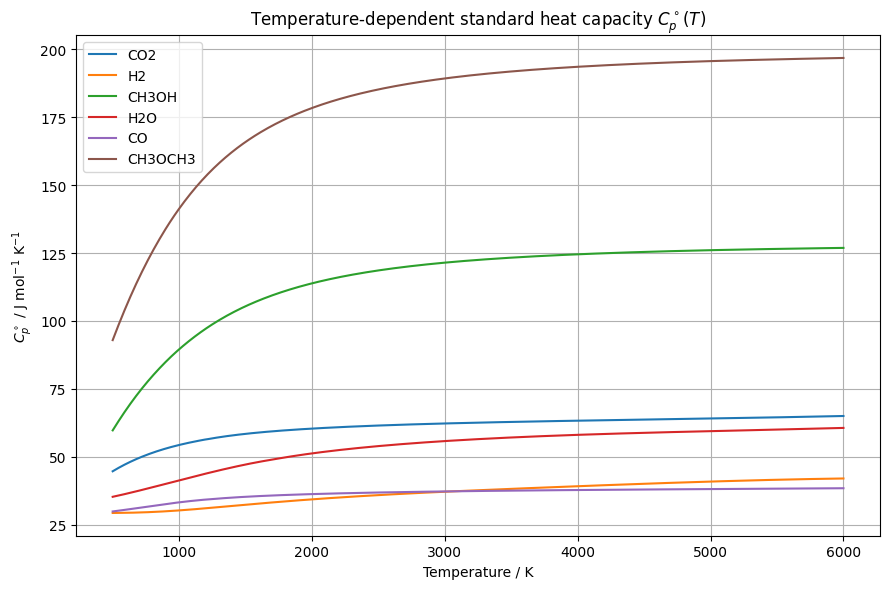

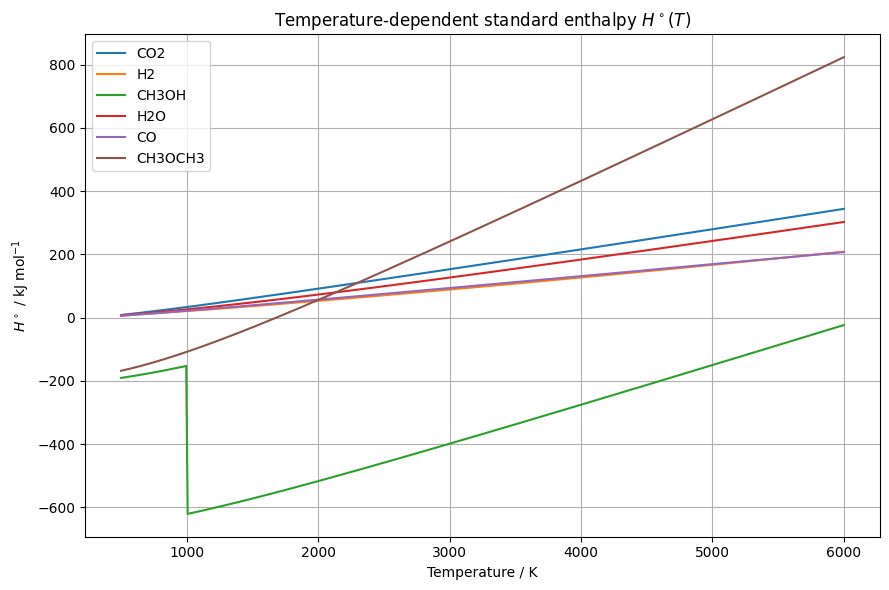

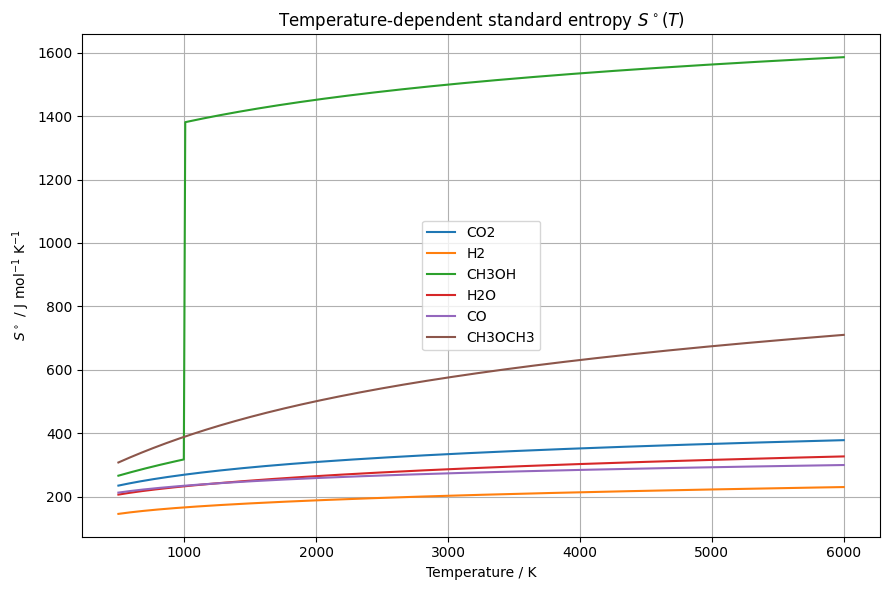

In [34]:
# Plot Cp, H and S for all species

# Plot heat capacity Cp
plt.figure(figsize=(9, 6))

for species in species_list:
    plt.plot(
        thermo_results[species]["T"],
        thermo_results[species]["Cp"],
        label=species
    )

plt.xlabel("Temperature / K")
plt.ylabel(r"$C_p^\circ$ / J mol$^{-1}$ K$^{-1}$")
plt.title(r"Temperature-dependent standard heat capacity $C_p^\circ(T)$")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# Plot standard enthalpy H
plt.figure(figsize=(9, 6))

for species in species_list:
    plt.plot(
        thermo_results[species]["T"],
        thermo_results[species]["H"],
        label=species
    )

plt.xlabel("Temperature / K")
plt.ylabel(r"$H^\circ$ / kJ mol$^{-1}$")
plt.title(r"Temperature-dependent standard enthalpy $H^\circ(T)$")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# Plot standard entropy S
plt.figure(figsize=(9, 6))

for species in species_list:
    plt.plot(
        thermo_results[species]["T"],
        thermo_results[species]["S"],
        label=species
    )

plt.xlabel("Temperature / K")
plt.ylabel(r"$S^\circ$ / J mol$^{-1}$ K$^{-1}$")
plt.title(r"Temperature-dependent standard entropy $S^\circ(T)$")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In order to validate the calculated values, data from the NIST database [2] is imported and can be plotted. In this case this is done for $CO_2$.

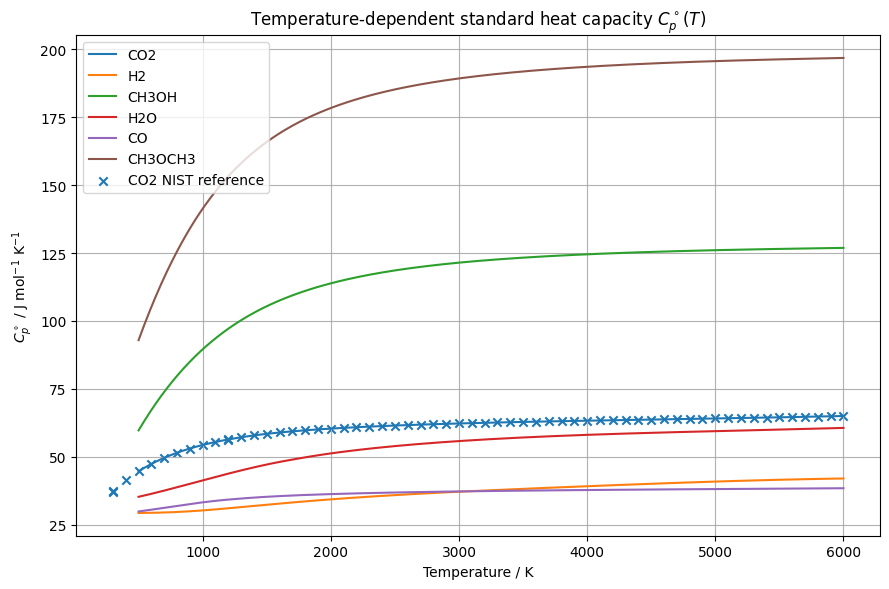

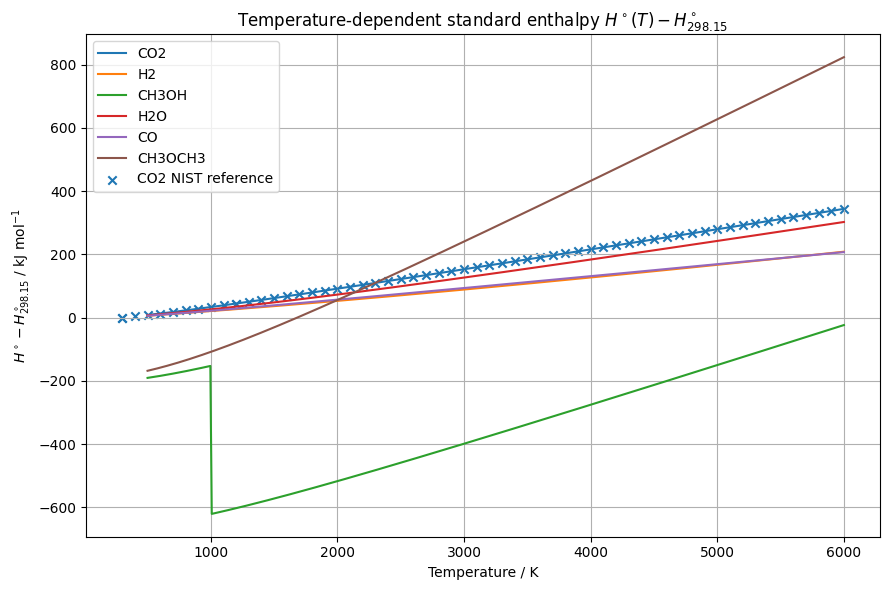

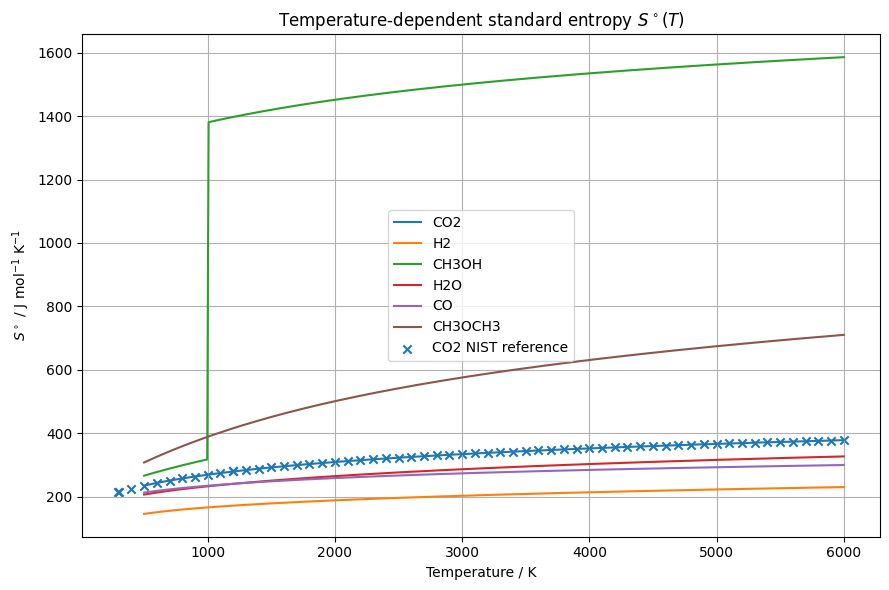

In [ ]:
# CO2 reference values from NIST

# Columns:
# T / K
# Cp / J mol-1 K-1
# S / J mol-1 K-1
# H - H_298.15 / kJ mol-1

CO2_reference = np.array([
    [298.0, 37.12, 213.8, -0.01],
    [300.0, 37.22, 214.0,  0.07],
    [400.0, 41.34, 225.3,  4.00],
    [500.0, 44.61, 234.9,  8.31],
    [600.0, 47.32, 243.3, 12.91],
    [700.0, 49.57, 250.8, 17.75],
    [800.0, 51.44, 257.5, 22.81],
    [900.0, 53.00, 263.6, 28.03],
    [1000.0, 54.30, 269.3, 33.40],
    [1100.0, 55.40, 274.5, 38.89],
    [1200.0, 56.35, 279.4, 44.47],
    [1200.0, 56.31, 279.4, 44.47],
    [1300.0, 57.14, 283.9, 50.15],
    [1400.0, 57.83, 288.2, 55.89],
    [1500.0, 58.40, 292.2, 61.71],
    [1600.0, 58.90, 296.0, 67.57],
    [1700.0, 59.33, 299.6, 73.48],
    [1800.0, 59.70, 303.0, 79.44],
    [1900.0, 60.04, 306.2, 85.42],
    [2000.0, 60.34, 309.3, 91.44],
    [2100.0, 60.61, 312.2, 97.49],
    [2200.0, 60.85, 315.1, 103.6],
    [2300.0, 61.07, 317.8, 109.7],
    [2400.0, 61.28, 320.4, 115.8],
    [2500.0, 61.47, 322.9, 121.9],
    [2600.0, 61.64, 325.3, 128.1],
    [2700.0, 61.80, 327.6, 134.2],
    [2800.0, 61.95, 329.9, 140.4],
    [2900.0, 62.10, 332.1, 146.6],
    [3000.0, 62.23, 334.2, 152.8],
    [3100.0, 62.35, 336.2, 159.1],
    [3200.0, 62.47, 338.2, 165.3],
    [3300.0, 62.59, 340.1, 171.6],
    [3400.0, 62.69, 342.0, 177.8],
    [3500.0, 62.80, 343.8, 184.1],
    [3600.0, 62.89, 345.6, 190.4],
    [3700.0, 62.99, 347.3, 196.7],
    [3800.0, 63.08, 349.0, 203.0],
    [3900.0, 63.17, 350.6, 209.3],
    [4000.0, 63.25, 352.2, 215.6],
    [4100.0, 63.34, 353.8, 222.0],
    [4200.0, 63.42, 355.3, 228.3],
    [4300.0, 63.50, 356.8, 234.6],
    [4400.0, 63.58, 358.3, 241.0],
    [4500.0, 63.66, 359.7, 247.4],
    [4600.0, 63.74, 361.1, 253.7],
    [4700.0, 63.82, 362.5, 260.1],
    [4800.0, 63.90, 363.8, 266.5],
    [4900.0, 63.98, 365.1, 272.9],
    [5000.0, 64.06, 366.4, 279.3],
    [5100.0, 64.14, 367.7, 285.7],
    [5200.0, 64.22, 368.9, 292.1],
    [5300.0, 64.31, 370.2, 298.5],
    [5400.0, 64.39, 371.4, 305.0],
    [5500.0, 64.48, 372.5, 311.4],
    [5600.0, 64.58, 373.7, 317.9],
    [5700.0, 64.67, 374.9, 324.3],
    [5800.0, 64.77, 376.0, 330.8],
    [5900.0, 64.87, 377.1, 337.3],
    [6000.0, 64.98, 378.2, 343.8],
])

T_CO2_ref = CO2_reference[:, 0]
Cp_CO2_ref = CO2_reference[:, 1]
S_CO2_ref = CO2_reference[:, 2]
H_CO2_ref = CO2_reference[:, 3]

# ------------------------------------------------------------
# Plot Cp with CO2 reference values
# ------------------------------------------------------------

plt.figure(figsize=(9, 6))

for species in species_list:
    plt.plot(
        thermo_results[species]["T"],
        thermo_results[species]["Cp"],
        label=species
    )

plt.scatter(
    T_CO2_ref,
    Cp_CO2_ref,
    label="CO2 NIST reference",
    marker="x"
)

plt.xlabel("Temperature / K")
plt.ylabel(r"$C_p^\circ$ / J mol$^{-1}$ K$^{-1}$")
plt.title(r"Temperature-dependent standard heat capacity $C_p^\circ(T)$")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Plot H with CO2 reference values
# ------------------------------------------------------------

plt.figure(figsize=(9, 6))

for species in species_list:
    plt.plot(
        thermo_results[species]["T"],
        thermo_results[species]["H"],
        label=species
    )

plt.scatter(
    T_CO2_ref,
    H_CO2_ref,
    label=r"CO2 NIST reference",
    marker="x"
)

plt.xlabel("Temperature / K")
plt.ylabel(r"$H^\circ - H^\circ_{298.15}$ / kJ mol$^{-1}$")
plt.title(r"Temperature-dependent standard enthalpy $H^\circ(T)-H^\circ_{298.15}$")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Plot S with CO2 reference values
# ------------------------------------------------------------

plt.figure(figsize=(9, 6))

for species in species_list:
    plt.plot(
        thermo_results[species]["T"],
        thermo_results[species]["S"],
        label=species
    )

plt.scatter(
    T_CO2_ref,
    S_CO2_ref,
    label="CO2 NIST reference",
    marker="x"
)

plt.xlabel("Temperature / K")
plt.ylabel(r"$S^\circ$ / J mol$^{-1}$ K$^{-1}$")
plt.title(r"Temperature-dependent standard entropy $S^\circ(T)$")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Comparison between calculated data and the NIST dataset show that $c_p$, $H$ and $S$ can be calculated using the Shomate equations from the given parameters. For other species, this check is done manually and therefore not integrated into the code.

# Sources

[1] Güttel, R., & Turek, T. (2021). *Chemische Reaktionstechnik*. Springer Spektrum. https://doi.org/10.1007/978-3-662-63150-8 

[2] Linstrom, P. J., & Mallard, W. G. (Eds.). (n.d.). *NIST Chemistry WebBook, NIST Standard Reference Database Number 69*. National Institute of Standards and Technology. Retrieved May 15, 2026, from https://webbook.nist.gov/

[3] McBride, B. J., Zehe, M. J., & Gordon, S. (2002). *NASA Glenn coefficients for calculating thermodynamic properties of individual species* (NASA/TP—2002-211556). National Aeronautics and Space Administration, Glenn Research Center. https://ntrs.nasa.gov/citations/20020085330